# Bayesian Ballot-Comparison Audit Demo

This notebook demonstrates the Bayesian ballot-comparison audit framework implemented in `src/bayesian_comparison.py`. The framework adapts Rivest's Bayesian audit approach for STV elections using VoteKit preference profiles.

We'll cover:
1. Basic operations: converting profiles to tallies and back
2. Initializing audit state with different priors
3. Recording ballot comparisons and updating posteriors
4. Sampling from posterior distributions
5. Running a complete end-to-end audit on a Scottish election

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from votekit.pref_profile import PreferenceProfile
from votekit.ballot import Ballot
from votekit.cvr_loaders import load_scottish

# Import our Bayesian audit module
from src.bayesian_comparison import (
    # Ballot type operations
    BallotType,
    ballot_row_to_type,
    enumerate_ballot_types,
    profile_to_reported_types,
    
    # Audit state management
    AuditState,
    initialize_audit_state,
    record_comparison,
    record_comparisons_batch,
    
    # Posterior simulation
    sample_row_posterior,
    sample_full_election_tally,
    run_stv_on_tally,
    
    # Audit stopping and reporting
    run_posterior_simulations,
    sequential_stopping_check,
    
    # Simulation helpers (using existing noise infrastructure)
    generate_noised_sample,
    simulate_audit_from_sample,
    
    # STV integration
    create_fast_stv,
)

from src.utils import convert_pf_to_numpy_arrays

## 1. Creating a Simple Test Profile

Let's start with a small example to understand the ballot type system.

In [2]:
# Create a simple 4-candidate, 2-seat election
ballots = [
    Ballot(ranking=(frozenset(["Alice"]), frozenset(["Bob"]), frozenset(["Carol"]))),
    Ballot(ranking=(frozenset(["Bob"]), frozenset(["Alice"]), frozenset(["Carol"]))),
    Ballot(ranking=(frozenset(["Carol"]), frozenset(["Alice"]))),
    Ballot(ranking=(frozenset(["Alice"]), frozenset(["Carol"]))),
    Ballot(ranking=(frozenset(["Dave"]),)),
]
candidates = ["Alice", "Bob", "Carol", "Dave"]
weights = [100, 80, 60, 70, 90]

simple_profile = PreferenceProfile(ballots=ballots, candidates=candidates)
simple_profile.df["Weight"] = weights

print(f"Total ballots: {sum(weights)}")
print(f"Unique ballot types: {len(ballots)}")
print(f"Candidates: {candidates}")

Total ballots: 400
Unique ballot types: 5
Candidates: ['Alice', 'Bob', 'Carol', 'Dave']


## 2. Ballot Type Enumeration

The audit framework works by enumerating all ballot types in the election and assigning each an integer index.

In [3]:
# Convert to numpy format and enumerate ballot types
ballot_matrix, wt_vec, fpv_vec = convert_pf_to_numpy_arrays(simple_profile)

print("Ballot matrix shape:", ballot_matrix.shape)
print("\nFirst few rows of ballot matrix:")
print(ballot_matrix[:5, :4])
print("\nWeights:", wt_vec[:5])

# Enumerate ballot types
types_list, type_to_idx, idx_to_type = enumerate_ballot_types(ballot_matrix)

print(f"\n{len(types_list)} unique ballot types found:")
for i, bt in enumerate(types_list):
    print(f"  Type {i}: {bt.ranking}")

Ballot matrix shape: (5, 4)

First few rows of ballot matrix:
[[   0    1    2 -126]
 [   1    0    2 -126]
 [   2    0 -127 -126]
 [   0    2 -127 -126]
 [   3 -127 -127 -126]]

Weights: [100.  80.  60.  70.  90.]

6 unique ballot types found:
  Type 0: (-2,)
  Type 1: (0, 1, 2)
  Type 2: (0, 2)
  Type 3: (1, 0, 2)
  Type 4: (2, 0)
  Type 5: (3,)


## 3. Converting Between Profiles and Type Tallies

The audit works with ballot type tallies. Let's see how to convert back and forth.

In [4]:
# Convert profile to reported type arrays
reported_type_by_ballot, R = profile_to_reported_types(simple_profile, type_to_idx)

print(f"Total ballots (expanded): {len(reported_type_by_ballot)}")
print(f"\nReported type totals (R):")
for type_idx, count in enumerate(R):
    if count > 0:
        bt = idx_to_type[type_idx]
        print(f"  Type {type_idx} {bt.ranking}: {count} ballots")

Total ballots (expanded): 400

Reported type totals (R):
  Type 1 (0, 1, 2): 100 ballots
  Type 2 (0, 2): 70 ballots
  Type 3 (1, 0, 2): 80 ballots
  Type 4 (2, 0): 60 ballots
  Type 5 (3,): 90 ballots


## 4. Initializing Audit State

We can initialize an audit with different prior choices.

In [5]:
# Initialize with Laplace prior (uniform hyperparameters of 1)
state_laplace = initialize_audit_state(
    simple_profile, 
    prior="laplace", 
    num_winners=2
)

print(f"Audit state initialized:")
print(f"  Number of ballot types (t): {state_laplace.t}")
print(f"  Total ballots (n): {state_laplace.n}")
print(f"  Reported type totals (R): {state_laplace.R}")
print(f"  Sample size: {state_laplace.sample_size}")
print(f"  Reported outcome: {state_laplace.reported_outcome}")

Audit state initialized:
  Number of ballot types (t): 6
  Total ballots (n): 400
  Reported type totals (R): [  0 100  70  80  60  90]
  Sample size: 0
  Reported outcome: (['Alice'], ['Bob'])


In [6]:
# The C matrix tracks observed ballot comparisons (all zeros initially)
print("Initial C matrix (observed counts):")
print(state_laplace.C)
print("\nPrior hyperparameters (alpha) - Laplace prior:")
print(state_laplace.alpha)

Initial C matrix (observed counts):
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]

Prior hyperparameters (alpha) - Laplace prior:
[[1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]]


## 5. Recording Ballot Comparisons

In a real audit, we sample ballots and compare the reported type to the actual (hand-inspected) type.

In [7]:
# Simulate some ballot comparisons
# Let's say we sample 10 ballots and find 1 discrepancy

# Sample 10 random ballots from the election (indices into reported_type_by_ballot)
np.random.seed(42)
sampled_ballot_indices = np.random.choice(len(reported_type_by_ballot), size=10, replace=False)

# Record 9 correct comparisons (reported type matches actual type)
for i in range(9):
    ballot_idx = sampled_ballot_indices[i]
    reported_type = reported_type_by_ballot[ballot_idx]
    actual_type = reported_type  # No error
    record_comparison(state_laplace, reported_type, actual_type)

# Record 1 discrepancy (reported type != actual type)
# Get the reported type for the 10th ballot and pick a different actual type
ballot_idx = sampled_ballot_indices[9]
reported_type = reported_type_by_ballot[ballot_idx]
# Pick a different type for the actual type (simple: use next type, wrapping around)
actual_type = (reported_type + 1) % state_laplace.t
record_comparison(state_laplace, reported_type_idx=reported_type, actual_type_idx=actual_type)

print(f"Sample size: {state_laplace.sample_size}")
print(f"Row sample sizes: {state_laplace.row_sample_sizes()}")
print(f"\nUpdated C matrix (observed counts):")
print(state_laplace.C)

Sample size: 10
Row sample sizes: [0 4 2 1 2 1]

Updated C matrix (observed counts):
[[0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 2 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 0 0 1 0]]


## 6. Posterior Simulation

Now we can sample from the posterior distribution over election outcomes.

In [8]:
# Sample one posterior draw of the full election tally
rng = np.random.default_rng(42)

# Sample a full election tally
type_tally = sample_full_election_tally(state_laplace, rng)

print("Posterior sample of ballot type tally:")
# Print known types (indices 0 to t-1)
for type_idx in range(state_laplace.t):
    count = type_tally[type_idx]
    if count > 0:
        bt = idx_to_type[type_idx]
        print(f"  Type {type_idx} {bt.ranking}: {count:.1f} ballots")

# Print unseen types (index t)
unseen_count = type_tally[state_laplace.t]
if unseen_count > 0:
    print(f"  Type {state_laplace.t} (unseen): {unseen_count:.1f} ballots")

print(f"\nTotal: {np.sum(type_tally):.1f} (should equal {state_laplace.n})")

Posterior sample of ballot type tally:
  Type 0 (-2,): 45.6 ballots
  Type 1 (0, 1, 2): 48.6 ballots
  Type 2 (0, 2): 64.5 ballots
  Type 3 (1, 0, 2): 36.1 ballots
  Type 4 (2, 0): 74.7 ballots
  Type 5 (3,): 69.2 ballots
  Type 6 (unseen): 61.4 ballots

Total: 400.0 (should equal 400)


In [9]:
# Run the STV tabulator on this posterior sample
outcome = run_stv_on_tally(type_tally, state_laplace)
print(f"Simulated outcome: {outcome}")
print(f"Reported outcome:  {state_laplace.reported_outcome}")
print(f"Match: {outcome == state_laplace.reported_outcome}")

Simulated outcome: (['Alice'], ['Carol'])
Reported outcome:  (['Alice'], ['Bob'])
Match: False


## 7. Estimating Upset Probability

We run many posterior simulations to estimate the probability that the reported outcome is wrong.

In [10]:
# Run 500 posterior simulations
results = run_posterior_simulations(state_laplace, num_simulations=500, seed=123)

print(f"Posterior upset probability: {results['upset_probability']:.4f}")
print(f"Number of simulations: {results['num_simulations']}")
print(f"\nUnique outcomes observed: {len(results['winner_set_counts'])}")

# Show the most common outcomes
sorted_outcomes = sorted(
    results['winner_set_counts'].items(), 
    key=lambda x: x[1], 
    reverse=True
)
print("\nTop 3 outcomes:")
for outcome_key, count in sorted_outcomes[:3]:
    print(f"  {outcome_key}: {count} times ({100*count/results['num_simulations']:.1f}%)")

Posterior upset probability: 0.7760
Number of simulations: 500

Unique outcomes observed: 3

Top 3 outcomes:
  (('Alice',), ('Carol',)): 360 times (72.0%)
  (('Alice',), ('Bob',)): 114 times (22.8%)
  (('Alice',), ('Dave',)): 26 times (5.2%)


## 8. Sequential Stopping Check

We can check if the audit should stop based on a risk limit.

In [11]:
can_stop, results = sequential_stopping_check(
    state_laplace, 
    risk_limit=0.05, 
    num_simulations=500, 
    seed=456
)

print(f"Risk limit: 0.05")
print(f"Posterior upset probability: {results['upset_probability']:.4f}")
print(f"Can stop? {can_stop}")

Risk limit: 0.05
Posterior upset probability: 0.7960
Can stop? False


## 9. End-to-End Audit on Scottish Election Data

Now let's run a complete audit on a real election from the Scottish local elections data.
We'll simulate an end-to-end audit with synthetic noise.

In [12]:
# Load a 5-candidate Scottish election
scottish_profile = load_scottish("data/scot-elex/5_cands/aberdeenshire_2017_ward7.csv")[0]

print(f"Scottish Election Profile:")
print(f"  Candidates: {scottish_profile.candidates}")
print(f"  Total ballots: {scottish_profile.total_ballot_wt}")
print(f"  Number of unique ballot types: {len(scottish_profile.ballots)}")

Scottish Election Profile:
  Candidates: ('Sandy Duncan', 'Alastair Forsyth', 'Mike Rawlins', 'Anne Robertson', 'Iain Taylor')
  Total ballots: 4963.0
  Number of unique ballot types: 279


In [13]:
# Generate a synthetic noised sample using the existing noise infrastructure
# This uses bal_cvr_sample_constructor which creates:
# - CVR: the reported cast vote record (possibly noised)
# - BAL: the true ballot as actually cast
error_rate = 0.02
num_ghosts = 10  # Add some empty ghost ballots
sample_size = min(500, int(scottish_profile.total_ballot_wt))

BAL, CVR = generate_noised_sample(
    scottish_profile, 
    sample_size=sample_size,
    noise_level=error_rate, 
    num_ghosts=num_ghosts,
    seed=2024
)

print(f"\nNoised sample generated:")
print(f"  Noise level: {error_rate}")
print(f"  Ghost ballots: {num_ghosts}")
print(f"  Sample size: {sample_size}")
print(f"  Original total ballots: {scottish_profile.total_ballot_wt}")

# Count discrepancies
num_discrepant = np.sum(np.any(BAL != CVR, axis=1))
print(f"\n  Discrepancies in sample: {num_discrepant}/{sample_size} ({100*num_discrepant/sample_size:.1f}%)")
print(f"  (Expected ~{100*error_rate:.1f}% based on noise_level={error_rate})")


Noised sample generated:
  Noise level: 0.02
  Ghost ballots: 10
  Sample size: 500
  Original total ballots: 4963.0

  Discrepancies in sample: 7/500 (1.4%)
  (Expected ~2.0% based on noise_level=0.02)


In [14]:
# Initialize audit state from the CVR/BAL sample
# The CVR becomes our "reported" ballots, BAL is the truth
# Audit only 50% of ballots to leave uncertainty for posterior
audit_state = simulate_audit_from_sample(
    CVR=CVR,
    BAL=BAL,
    candidates=list(scottish_profile.candidates),
    prior="laplace",
    num_winners=3,
    audit_fraction=0.5,
    seed=2024
)

print(f"\nAudit State:")
print(f"  Number of ballot types: {audit_state.t}")
print(f"  Total ballots sampled: {audit_state.sample_size}")

print(f"  Reported outcome: {audit_state.reported_outcome}")
print(f"  Discrepancy rate: {100*(1 - np.trace(audit_state.C)/audit_state.sample_size):.2f}%")
print(f"\n  Total discrepancies recorded: {audit_state.sample_size - np.trace(audit_state.C)}")


Audit State:
  Number of ballot types: 135
  Total ballots sampled: 250
  Reported outcome: (['Iain Taylor'], ['Alastair Forsyth'], ['Anne Robertson'])
  Discrepancy rate: 0.80%

  Total discrepancies recorded: 2


### Sequential Sampling and Updating

Now we'll simulate a sequential audit: sample some ballots, record comparisons, check the stopping rule, repeat.

In [15]:
# Simulate sequential auditing by gradually adding ballots from our sample  
# We'll start with a small subsample and gradually increase
risk_limit = 0.05
batch_size = 20  # Add this many ballots at a time

# Shuffle the order of ballot indices for random sampling
rng = np.random.default_rng(789)
sample_order = rng.permutation(audit_state.sample_size)

# Track audit progress
audit_history = []

print(f"Starting sequential audit simulation:")
print(f"  Risk limit: {risk_limit}")
print(f"  Batch size: {batch_size}")
print(f"  Total sample available: {audit_state.sample_size}")
print()

# Start fresh with a new audit state
candidates_list = list(scottish_profile.candidates)

for target_sample in range(batch_size, audit_state.sample_size + 1, batch_size):
    # Get the subsample up to target_sample
    subsample_indices = sample_order[:target_sample]
    
    # Create audit state from this subsample
    cvr_sub = CVR[subsample_indices]
    bal_sub = BAL[subsample_indices]
    
    state_sub = simulate_audit_from_sample(
        CVR=cvr_sub,
        BAL=bal_sub,
        candidates=candidates_list,
        prior="haldane",
        num_winners=3,
        audit_fraction=0.5,
        seed=789 + target_sample
    )
    
    # Check stopping condition
    can_stop, results = sequential_stopping_check(
        state_sub,
        risk_limit=risk_limit,
        num_simulations=1000,
        seed=789 + target_sample
    )
    
    # Count discrepancies in this subsample
    num_discrepancies = 0
    for i in range(target_sample):
        idx = subsample_indices[i]
        if not np.array_equal(CVR[idx, :], BAL[idx, :]):
            num_discrepancies += 1
    
    # Record history
    audit_history.append({
        'sample_size': target_sample,
        'upset_probability': results['upset_probability'],
        'can_stop': can_stop,
        'num_discrepancies': num_discrepancies
    })
    
    round_num = len(audit_history)
    print(f"Round {round_num:2d}: n={target_sample:3d}, "
          f"upset_prob={results['upset_probability']:.4f}, "
          f"stop={can_stop}")
    
    if can_stop:
        print(f"\n✓ Audit can stop! Sampled {target_sample} ballots.")
        audit_state = state_sub  # Update to the final state
        break
else:
    print(f"\n⚠ Audit did not achieve risk limit with {audit_state.sample_size} ballots.")
    # Use the full sample state
    audit_state = simulate_audit_from_sample(CVR, BAL, candidates_list, "laplace", 3, audit_fraction=0.5, seed=2024)

Starting sequential audit simulation:
  Risk limit: 0.05
  Batch size: 20
  Total sample available: 250

Round  1: n= 20, upset_prob=0.5540, stop=False
Round  2: n= 40, upset_prob=0.1420, stop=False
Round  3: n= 60, upset_prob=0.7910, stop=False
Round  4: n= 80, upset_prob=0.0000, stop=True

✓ Audit can stop! Sampled 80 ballots.


In [16]:
# Show the final audit state
print("\nFinal Audit State:")
print(f"  Total sampled: {audit_state.sample_size} / {audit_state.n}")
print(f"  Sampling rate: {100 * audit_state.sample_size / audit_state.n:.1f}%")
print(f"  Row sample sizes: {audit_state.row_sample_sizes()[:10]}...")  # First 10 rows
print(f"  Unaudited counts: {audit_state.unaudited_counts()[:10]}...")

# Count total discrepancies
total_discrepancies = 0
for j in range(audit_state.t):
    for k in range(audit_state.t):
        if j != k:
            total_discrepancies += audit_state.C[j, k]

print(f"\n  Total discrepancies found: {total_discrepancies}")
print(f"  Discrepancy rate: {100 * total_discrepancies / audit_state.sample_size:.2f}%")
print(f"  (Expected ~{100 * error_rate:.1f}% based on error_rate={error_rate})")


Final Audit State:
  Total sampled: 40 / 80
  Sampling rate: 50.0%
  Row sample sizes: [0 0 0 1 0 1 0 1 0 1]...
  Unaudited counts: [1 1 1 1 1 0 2 0 1 0]...

  Total discrepancies found: 2
  Discrepancy rate: 5.00%
  (Expected ~2.0% based on error_rate=0.02)


### Visualizing Audit Progress

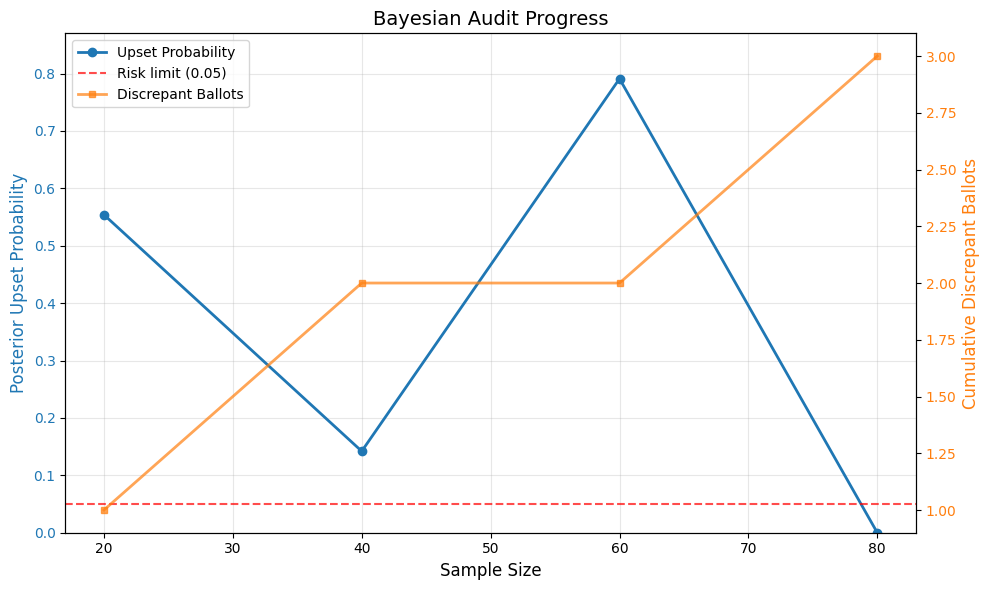

In [17]:
# Plot the upset probability over the course of the audit
import matplotlib.pyplot as plt

if audit_history:
    sample_sizes = [h['sample_size'] for h in audit_history]
    upset_probs = [h['upset_probability'] for h in audit_history]
    num_discrepancies = [h['num_discrepancies'] for h in audit_history]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot upset probability on left y-axis
    color = 'tab:blue'
    ax1.set_xlabel('Sample Size', fontsize=12)
    ax1.set_ylabel('Posterior Upset Probability', fontsize=12, color=color)
    ax1.plot(sample_sizes, upset_probs, 'o-', linewidth=2, markersize=6, color=color, label='Upset Probability')
    ax1.axhline(y=risk_limit, color='red', linestyle='--', alpha=0.7, label=f'Risk limit ({risk_limit})')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, max(upset_probs) * 1.1 if max(upset_probs) > 0 else 0.1])
    
    # Plot cumulative discrepancies on right y-axis
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Cumulative Discrepant Ballots', fontsize=12, color=color)
    ax2.plot(sample_sizes, num_discrepancies, 's-', linewidth=2, markersize=5, color=color, alpha=0.7, label='Discrepant Ballots')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Add title and legends
    ax1.set_title('Bayesian Audit Progress', fontsize=14)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    fig.tight_layout()
    plt.show()
else:
    print("No audit history to plot")    

### Final Posterior Analysis

Let's run a large number of simulations on the final audit state to get a precise estimate.

In [18]:
# Run a final detailed posterior simulation
final_results = run_posterior_simulations(
    audit_state, 
    num_simulations=2000, 
    seed=9999
)

print("Final Posterior Analysis:")
print(f"  Simulations run: {final_results['num_simulations']}")
print(f"  Upset probability: {final_results['upset_probability']:.5f}")
print(f"  Risk limit: {risk_limit}")
print(f"  Audit successful: {final_results['upset_probability'] <= risk_limit}")

print(f"\n  Unique outcomes observed: {len(final_results['winner_set_counts'])}")

# Show all observed outcomes
sorted_outcomes = sorted(
    final_results['winner_set_counts'].items(), 
    key=lambda x: x[1], 
    reverse=True
)

print("\nAll observed outcomes:")
for i, (outcome_key, count) in enumerate(sorted_outcomes, 1):
    prob = count / final_results['num_simulations']
    print(f"  {i}. {outcome_key}")
    print(f"     {count:4d} times ({100*prob:.2f}%)")

Final Posterior Analysis:
  Simulations run: 2000
  Upset probability: 0.00000
  Risk limit: 0.05
  Audit successful: True

  Unique outcomes observed: 1

All observed outcomes:
  1. (('Alastair Forsyth',), ('Anne Robertson',), ('Sandy Duncan',))
     2000 times (100.00%)


## Summary

This notebook demonstrated:

1. **Ballot type enumeration**: Converting STV ballots to integer-indexed types
2. **Profile ↔ tally conversion**: Moving between VoteKit profiles and ballot type tallies
3. **Audit initialization**: Setting up audit state with different priors (Haldane, Laplace, custom)
4. **Sequential updating**: Recording ballot comparisons and updating the C matrix
5. **Posterior sampling**: Using the gamma/Dirichlet method to sample from the posterior
6. **Outcome determination**: Running FastSTV on posterior samples
7. **Stopping rules**: Checking when upset probability falls below the risk limit
8. **End-to-end audit**: Complete workflow on a real Scottish election with synthetic noise

The Bayesian framework provides a principled way to audit STV elections with informative stopping rules based on posterior probabilities rather than fixed sample sizes.

## 🚨 Adversarial Stress Test

This test evaluates the audit framework against a **strategically manipulated CVR** designed to change the election outcome.

**Scenario:**
- 5 candidates: A, B, C, D, E
- 2 winners (m=2), quota = 1000
- 2997 total ballots
- **Attack:** 59 ballots moved from "E>A" to "D>A" (2% manipulation)
- This strategic change targets A's transfers to swing the outcome

**Goals:**
1. Verify the manipulation changes the STV outcome
2. Test if the audit detects the manipulation
3. Evaluate sample sizes needed for detection

In [19]:
# Create the adversarial profiles
candidates_adv = ['A', 'B', 'C', 'D', 'E']

# Ballot types with rankings
# Type 1: A > B
ballot_1 = Ballot(ranking=(frozenset(['A']), frozenset(['B'])))
# Type 2: B only
ballot_2 = Ballot(ranking=(frozenset(['B']),))
# Type 3: C only
ballot_3 = Ballot(ranking=(frozenset(['C']),))
# Type 4: D > A
ballot_4 = Ballot(ranking=(frozenset(['D']), frozenset(['A'])))
# Type 5: E > A
ballot_5 = Ballot(ranking=(frozenset(['E']), frozenset(['A'])))

# CVR weights (manipulated)
cvr_weights = [800, 600, 800, 258, 539]
# True weights
true_weights = [800, 600, 800, 199, 598]

print("Adversarial Election Setup:")
print(f"  Candidates: {candidates_adv}")
print(f"  Ballot types: 5")
print(f"  Total ballots (CVR): {sum(cvr_weights)}")
print(f"  Total ballots (True): {sum(true_weights)}")
print(f"  Manipulation: {sum(cvr_weights) - sum(true_weights)} ballots (moved from Type 5 to Type 4)")
print(f"  Noise level: {abs(258-199)/sum(true_weights):.2%}")

# Create profiles
cvr_profile = PreferenceProfile(
    ballots=[ballot_1, ballot_2, ballot_3, ballot_4, ballot_5],
    candidates=candidates_adv
)
cvr_profile.df['Weight'] = cvr_weights

true_profile = PreferenceProfile(
    ballots=[ballot_1, ballot_2, ballot_3, ballot_4, ballot_5],
    candidates=candidates_adv
)
true_profile.df['Weight'] = true_weights

print(f"\nCVR Profile:\n{cvr_profile.df}")
print(f"\nTrue Profile:\n{true_profile.df}")

Adversarial Election Setup:
  Candidates: ['A', 'B', 'C', 'D', 'E']
  Ballot types: 5
  Total ballots (CVR): 2997
  Total ballots (True): 2997
  Manipulation: 0 ballots (moved from Type 5 to Type 4)
  Noise level: 1.97%

CVR Profile:
                   Ranking_1       Ranking_2 Voter Set  Weight
Ballot Index                                                  
0             frozenset({A})  frozenset({B})        {}     800
1             frozenset({B})  frozenset({~})        {}     600
2             frozenset({C})  frozenset({~})        {}     800
3             frozenset({D})  frozenset({A})        {}     258
4             frozenset({E})  frozenset({A})        {}     539

True Profile:
                   Ranking_1       Ranking_2 Voter Set  Weight
Ballot Index                                                  
0             frozenset({A})  frozenset({B})        {}     800
1             frozenset({B})  frozenset({~})        {}     600
2             frozenset({C})  frozenset({~})        {}    

In [20]:
# Step 1: Verify the manipulation changes the outcome

# Run STV on CVR
cvr_ballot_matrix, cvr_wt_vec, _ = convert_pf_to_numpy_arrays(cvr_profile)
cvr_stv = create_fast_stv(
    ballot_matrix=cvr_ballot_matrix,
    wt_vec=cvr_wt_vec,
    candidates=candidates_adv,
    num_winners=2,
    profile=cvr_profile
)
cvr_outcome = cvr_stv.get_elected(no_fsets=False)

# Run STV on true profile
true_ballot_matrix, true_wt_vec, _ = convert_pf_to_numpy_arrays(true_profile)
true_stv = create_fast_stv(
    ballot_matrix=true_ballot_matrix,
    wt_vec=true_wt_vec,
    candidates=candidates_adv,
    num_winners=2,
    profile=true_profile
)
true_outcome = true_stv.get_elected(no_fsets=False)

print("Step 1: Outcome Verification")
print(f"  CVR outcome:  {cvr_outcome}")
print(f"  True outcome: {true_outcome}")
print(f"  Outcomes differ: {cvr_outcome != true_outcome}")

if cvr_outcome == true_outcome:
    print("\n⚠️ WARNING: Manipulation did NOT change the outcome!")
    print("   This test case needs adjustment.")
else:
    print("\n✓ Manipulation successfully changed the outcome.")
    print("  This is an upset that the audit should detect.")

Step 1: Outcome Verification
  CVR outcome:  (['A'], ['C'])
  True outcome: (['A'], ['B'])
  Outcomes differ: True

✓ Manipulation successfully changed the outcome.
  This is an upset that the audit should detect.


In [21]:
# Step 2: Create CVR and BAL matrices for the audit

# We need to carefully construct the matrices so discrepancies are properly aligned
# The manipulation: 59 ballots that are truly "E>A" are reported as "D>A" in CVR

# Both profiles have 2997 ballots total
# Let's construct them ballot-by-ballot:
#   Ballots 0-799: Type 1 (A>B) - no discrepancy
#   Ballots 800-1399: Type 2 (B) - no discrepancy
#   Ballots 1400-2199: Type 3 (C) - no discrepancy
#   Ballots 2200-2398: Type 4 (D>A) - no discrepancy (199 ballots)
#   Ballots 2399-2457: DISCREPANCY - CVR says Type 4 (D>A), BAL says Type 5 (E>A) (59 ballots)
#   Ballots 2458-2996: Type 5 (E>A) - no discrepancy (539 ballots)

# Get the ballot patterns
type_1_row = cvr_ballot_matrix[0, :]  # A>B
type_2_row = cvr_ballot_matrix[1, :]  # B
type_3_row = cvr_ballot_matrix[2, :]  # C
type_4_row = cvr_ballot_matrix[3, :]  # D>A
type_5_row = cvr_ballot_matrix[4, :]  # E>A

# Construct CVR matrix
CVR_adv = np.vstack([
    np.tile(type_1_row, (800, 1)),    # Type 1: 800 ballots
    np.tile(type_2_row, (600, 1)),    # Type 2: 600 ballots
    np.tile(type_3_row, (800, 1)),    # Type 3: 800 ballots
    np.tile(type_4_row, (258, 1)),    # Type 4: 258 ballots (199 correct + 59 false)
    np.tile(type_5_row, (539, 1)),    # Type 5: 539 ballots
])

# Construct BAL matrix (truth)
BAL_adv = np.vstack([
    np.tile(type_1_row, (800, 1)),    # Type 1: 800 ballots
    np.tile(type_2_row, (600, 1)),    # Type 2: 600 ballots
    np.tile(type_3_row, (800, 1)),    # Type 3: 800 ballots
    np.tile(type_4_row, (199, 1)),    # Type 4: 199 ballots (correct)
    np.tile(type_5_row, (598, 1)),    # Type 5: 598 ballots (539 correct + 59 falsely labeled as Type 4)
])

print("Step 2: Ballot Matrix Construction")
print(f"  CVR matrix shape: {CVR_adv.shape}")
print(f"  BAL matrix shape: {BAL_adv.shape}")

# Count discrepancies by comparing each ballot
num_discrepancies_adv = 0
for i in range(CVR_adv.shape[0]):
    cvr_bt = ballot_row_to_type(CVR_adv[i, :])
    bal_bt = ballot_row_to_type(BAL_adv[i, :])
    if cvr_bt != bal_bt:
        num_discrepancies_adv += 1

print(f"\n  Total discrepancies: {num_discrepancies_adv}")
print(f"  Discrepancy rate: {100 * num_discrepancies_adv / CVR_adv.shape[0]:.2f}%")
print(f"  Expected: 59 discrepancies (1.97%)")

if num_discrepancies_adv != 59:
    print(f"\n⚠️ WARNING: Expected 59 discrepancies, found {num_discrepancies_adv}")

Step 2: Ballot Matrix Construction
  CVR matrix shape: (2997, 3)
  BAL matrix shape: (2997, 3)

  Total discrepancies: 59
  Discrepancy rate: 1.97%
  Expected: 59 discrepancies (1.97%)


In [22]:
# Step 3: Run the audit on the adversarial profile

# Initialize audit state from the CVR/BAL comparison
# Audit only 50% of ballots to allow posterior uncertainty
audit_state_adv = simulate_audit_from_sample(
    CVR=CVR_adv,
    BAL=BAL_adv,
    candidates=candidates_adv,
    prior="laplace",
    num_winners=2,
    unseen_prior_mass=1.0,
    audit_fraction=0.5,
    seed=12345
)

print("Step 3: Audit State Initialization")
print(f"  Number of ballot types: {audit_state_adv.t}")
print(f"  Total ballots: {audit_state_adv.n}")
print(f"  Reported outcome: {audit_state_adv.reported_outcome}")
print(f"  Comparisons recorded: {audit_state_adv.sample_size}")

# Count discrepancies
total_discrepancies_adv = 0
for j in range(audit_state_adv.t):
    for k in range(audit_state_adv.t + 1):
        if k < audit_state_adv.t and j != k:
            total_discrepancies_adv += audit_state_adv.C[j, k]
        elif k == audit_state_adv.t:  # Unseen column
            total_discrepancies_adv += audit_state_adv.C[j, k]

print(f"  Discrepancy rate: {100 * total_discrepancies_adv / audit_state_adv.sample_size:.2f}%")
print(f"\n  Discrepancies in audit: {total_discrepancies_adv}")

Step 3: Audit State Initialization
  Number of ballot types: 5
  Total ballots: 2997
  Reported outcome: (['A'], ['C'])
  Comparisons recorded: 1499
  Discrepancy rate: 2.27%

  Discrepancies in audit: 34


In [23]:
# Step 4: Test stopping rule with full sample

# Run posterior simulations on the full audit
results_adv_full = run_posterior_simulations(
    audit_state_adv,
    num_simulations=2000,
    seed=12345
)

print("Step 4: Full-Sample Audit Results")
print(f"  Reported outcome: {audit_state_adv.reported_outcome}")
print(f"  Upset probability: {results_adv_full['upset_probability']:.5f}")
print(f"  Risk limit: 0.05")
print(f"  Would certify? {results_adv_full['upset_probability'] <= 0.05}")

print(f"\n  Unique outcomes observed: {len(results_adv_full['winner_set_counts'])}")
print("  Outcome distribution:")
sorted_outcomes_adv = sorted(
    results_adv_full['winner_set_counts'].items(),
    key=lambda x: x[1],
    reverse=True
)
for outcome_key, count in sorted_outcomes_adv[:5]:  # Top 5
    prob = count / results_adv_full['num_simulations']
    print(f"    {outcome_key}: {count} ({100*prob:.2f}%)")

# Check if we would incorrectly certify
if results_adv_full['upset_probability'] <= 0.05:
    print("\n⚠️ FALSE CERTIFICATION: Audit would certify the wrong outcome!")
    print(f"   True outcome:     {true_outcome}")
    print(f"   Reported outcome: {cvr_outcome}")
else:
    print("\n✓ CORRECT DETECTION: Audit correctly identifies the manipulation.")

Step 4: Full-Sample Audit Results
  Reported outcome: (['A'], ['C'])
  Upset probability: 0.06750
  Risk limit: 0.05
  Would certify? False

  Unique outcomes observed: 2
  Outcome distribution:
    (('A',), ('C',)): 1865 (93.25%)
    (('A',), ('B',)): 135 (6.75%)

✓ CORRECT DETECTION: Audit correctly identifies the manipulation.


In [24]:
# Step 5: Sequential audit simulation - how many samples needed?

print("Step 5: Sequential Audit Simulation")
print(f"  Testing with increasing sample sizes...")
print(f"  Risk limit: 0.05\n")

# Test with increasing sample sizes
sample_sizes_to_test = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200] #[50, 100, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 2997]

rng_adv = np.random.default_rng(54321)
sample_order_adv = rng_adv.permutation(audit_state_adv.n)

results_by_size = []

for sample_size_test in sample_sizes_to_test:
    # Create sub-audit with first sample_size_test ballots
    subsample_indices_adv = sample_order_adv[:sample_size_test]
    
    # Build sub-matrices
    CVR_sub_adv = CVR_adv[subsample_indices_adv, :]
    BAL_sub_adv = BAL_adv[subsample_indices_adv, :]
    
    # Create sub-audit state
    state_sub_adv = simulate_audit_from_sample(
        CVR=CVR_sub_adv,
        BAL=BAL_sub_adv,
        candidates=candidates_adv,
        prior="laplace",
        num_winners=2,
        unseen_prior_mass=1.0,
        audit_fraction=0.5,
        seed=99999 + sample_size_test
    )
    
    # Run posterior
    results_sub_adv = run_posterior_simulations(
        state_sub_adv,
        num_simulations=1000,
        seed=99999
    )
    
    upset_prob = results_sub_adv['upset_probability']
    can_stop = upset_prob <= 0.05
    
    # Count discrepancies in subsample
    num_discrepancies_sub = 0
    for i in range(sample_size_test):
        idx = subsample_indices_adv[i]
        if not np.array_equal(CVR_adv[idx, :], BAL_adv[idx, :]):
            num_discrepancies_sub += 1
    
    results_by_size.append({
        'sample_size': sample_size_test,
        'upset_prob': upset_prob,
        'can_stop': can_stop,
        'discrepancies': num_discrepancies_sub
    })
    
    status = "STOP ✓" if can_stop else "CONTINUE"
    print(f"  n={sample_size_test:4d}: upset_prob={upset_prob:.5f}, discrepancies={num_discrepancies_sub:2d}, {status}")

# Find minimum sample size to detect
min_detect_size = None
for result in results_by_size:
    if not result['can_stop']:
        min_detect_size = result['sample_size']
        break

if min_detect_size:
    print(f"\n  Minimum sample to detect manipulation: {min_detect_size} ballots ({100*min_detect_size/2997:.1f}%)")

else:    print(f"\n  ⚠️ WARNING: Audit never detects manipulation even at full sample!")

Step 5: Sequential Audit Simulation
  Testing with increasing sample sizes...
  Risk limit: 0.05

  n=  10: upset_prob=0.47500, discrepancies= 0, CONTINUE
  n=  20: upset_prob=0.54200, discrepancies= 0, CONTINUE
  n=  30: upset_prob=0.14400, discrepancies= 1, CONTINUE
  n=  40: upset_prob=0.24800, discrepancies= 2, CONTINUE
  n=  50: upset_prob=0.91500, discrepancies= 2, CONTINUE
  n=  60: upset_prob=0.60700, discrepancies= 2, CONTINUE
  n=  70: upset_prob=0.34600, discrepancies= 2, CONTINUE
  n=  80: upset_prob=0.18900, discrepancies= 2, CONTINUE
  n=  90: upset_prob=0.03900, discrepancies= 2, STOP ✓
  n= 100: upset_prob=0.08100, discrepancies= 2, CONTINUE
  n= 110: upset_prob=0.04500, discrepancies= 2, STOP ✓
  n= 120: upset_prob=0.04200, discrepancies= 2, STOP ✓
  n= 130: upset_prob=0.00500, discrepancies= 2, STOP ✓
  n= 140: upset_prob=0.01000, discrepancies= 2, STOP ✓
  n= 150: upset_prob=0.03100, discrepancies= 2, STOP ✓
  n= 160: upset_prob=0.01300, discrepancies= 2, STOP ✓
  n=

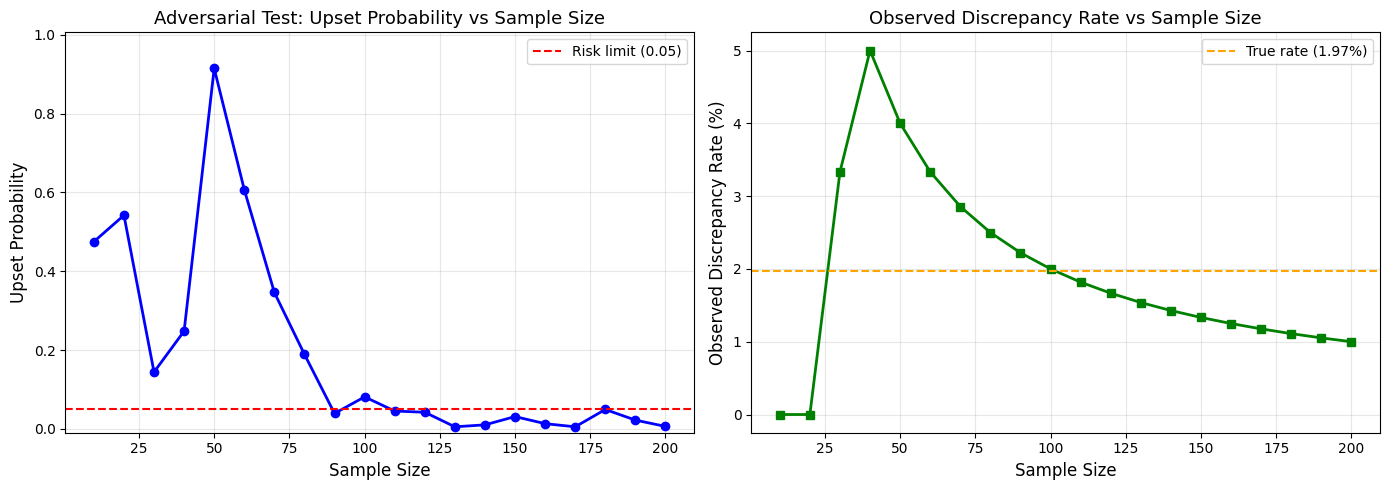


ADVERSARIAL STRESS TEST SUMMARY
Manipulation: 59 ballots (1.97%) strategically moved
  From: E>A (Type 5)
  To:   D>A (Type 4)

Outcome Change:
  CVR outcome:  (['A'], ['C'])
  True outcome: (['A'], ['B'])
  Different: True

Audit Performance:
  Detection threshold: 10 ballots (0.3%)
  At 50 ballots: upset_prob = 0.47500
  At full sample: upset_prob = 0.06750


In [25]:
# Analysis: Why the audit might fail (or succeed)

import matplotlib.pyplot as plt

# Plot upset probability vs sample size
sample_sizes = [r['sample_size'] for r in results_by_size]
upset_probs = [r['upset_prob'] for r in results_by_size]
discrepancy_rates = [100 * r['discrepancies'] / r['sample_size'] for r in results_by_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Upset probability
ax1.plot(sample_sizes, upset_probs, 'b-o', linewidth=2, markersize=6)
ax1.axhline(y=0.05, color='r', linestyle='--', label='Risk limit (0.05)')
ax1.set_xlabel('Sample Size', fontsize=12)
ax1.set_ylabel('Upset Probability', fontsize=12)
ax1.set_title('Adversarial Test: Upset Probability vs Sample Size', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim([-0.01, max(upset_probs) * 1.1])

# Plot 2: Observed discrepancy rate
ax2.plot(sample_sizes, discrepancy_rates, 'g-s', linewidth=2, markersize=6)
ax2.axhline(y=1.97, color='orange', linestyle='--', label='True rate (1.97%)')
ax2.set_xlabel('Sample Size', fontsize=12)
ax2.set_ylabel('Observed Discrepancy Rate (%)', fontsize=12)
ax2.set_title('Observed Discrepancy Rate vs Sample Size', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ADVERSARIAL STRESS TEST SUMMARY")
print("="*70)
print(f"Manipulation: {59} ballots (1.97%) strategically moved")
print(f"  From: E>A (Type 5)")
print(f"  To:   D>A (Type 4)")
print(f"\nOutcome Change:")
print(f"  CVR outcome:  {cvr_outcome}")
print(f"  True outcome: {true_outcome}")
print(f"  Different: {cvr_outcome != true_outcome}")
print(f"\nAudit Performance:")
if min_detect_size:
    print(f"  Detection threshold: {min_detect_size} ballots ({100*min_detect_size/2997:.1f}%)")
    print(f"  At 50 ballots: upset_prob = {results_by_size[0]['upset_prob']:.5f}")
    print(f"  At full sample: upset_prob = {results_adv_full['upset_probability']:.5f}")
else:
    print(f"  ⚠️ FAILURE: Never detects manipulation")
print("="*70)